Style Transfer According to Gatys et al. (2016)

[Paper Link](https://www.cv-foundation.org/openaccess/content_cvpr_2016/papers/Gatys_Image_Style_Transfer_CVPR_2016_paper.pdf)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array, array_to_img
import matplotlib.pyplot as plt
import time
import os
from tqdm import tqdm
from scipy.optimize import fmin_l_bfgs_b

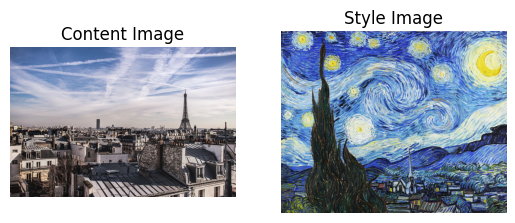

In [ ]:
# Global constants
CONTENT_WEIGHT = 8e-4
STYLE_WEIGHT = 1
MAX_DIM = 256  # Reduced image size to avoid memory issues
ITERATIONS = 5000

# Define content and style layers according to the paper
CONTENT_LAYER = 'block4_conv2'
STYLE_LAYERS = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

path_to_proj = "/content/drive/MyDrive/Master's/Second Year Grad/CV/CV Final Project"
content_img = "images/paris.jpg"
style_img = "vangogh/starry_night.jpg"

save_dir = os.path.join(path_to_proj, 'code/Final_Implementations/results')

content_path = os.path.join(path_to_proj, 'code/dataset', content_img)
style_path = os.path.join(path_to_proj, 'code/dataset', style_img)

# making save_dir if needed
os.makedirs(save_dir, exist_ok=True)

# showing initial images
fig, axs = plt.subplots(1, 2)

axs[0].set_title('Content Image')
axs[1].set_title('Style Image')

axs[0].axis('off')
axs[1].axis('off')
axs[0].imshow(plt.imread(content_path))
axs[1].imshow(plt.imread(style_path))
plt.show()

Load in images

In [ ]:
def load_and_process_image(path, max_dim=MAX_DIM):
    """Load and preprocess an image for VGG19 with smaller dimensions."""
    img = load_img(path)

    # Resize image while preserving aspect ratio
    long_dim = max(img.size)
    scale = max_dim / long_dim
    new_size = tuple([int(dim * scale) for dim in img.size])
    img = img.resize(new_size)

    # Convert to array and add batch dimension
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Preprocess for VGG19
    img_array = preprocess_input(img_array)

    return img_array

In [ ]:
def deprocess_image(processed_img):
    """Convert processed image back to displayable format."""
    x = processed_img.copy()

    # Remove batch dimension
    if len(x.shape) == 4:
        x = np.squeeze(x, axis=0)

    # Undo VGG preprocessing
    x[:, :, 0] += 103.939
    x[:, :, 1] += 116.779
    x[:, :, 2] += 123.68
    x = x[:, :, ::-1]  # Convert BGR to RGB

    # Clip to valid range
    x = np.clip(x, 0, 255).astype('uint8')

    return x

In [ ]:
content_image = load_and_process_image(content_path)
style_image = load_and_process_image(style_path)

Defining loss and helper functions

In [ ]:
def gram_matrix(input_tensor):
    """Memory-efficient implementation of Gram matrix calculation."""
    # Ensure we're working with float32
    input_tensor = tf.cast(input_tensor, tf.float32)

    # Get dimensions
    shape = tf.shape(input_tensor)
    batch_size, height, width, num_filters = shape[0], shape[1], shape[2], shape[3]

    # Reshape the tensor: [batch_size, (height * width), num_filters]
    features = tf.reshape(input_tensor, (batch_size, height * width, num_filters))

    # Calculate gram matrix with batched matmul for better memory efficiency
    # G = F * F^T
    gram = tf.matmul(features, features, transpose_a=True)

    # Normalize by dividing by the number of locations (height * width)
    #gram = gram / tf.cast(height * width, tf.float32)

    return gram

In [ ]:
@tf.function
def compute_content_loss(content_features, target_features):
    """Compute content loss as per the paper."""
    return (1/2) * tf.reduce_sum(tf.square(content_features - target_features))

In [ ]:
@tf.function
def compute_style_layer_loss(style_features, target_features):
    """Compute style loss as per the paper."""
    target_gram = gram_matrix(target_features)
    style_gram = gram_matrix(style_features)

    N_l, M_l = target_features.shape[-1], target_features.shape[1]*target_features.shape[2]
    M_l = np.max([M_l, 1e-9]) # making sure it's not zero
    E_l = 1/(4*(N_l**2)*(M_l**2)) * tf.reduce_sum(tf.square(style_gram - target_gram))

    return E_l

In [ ]:
@tf.function
def compute_loss(model, image, content_features, style_features):
    """Compute the total loss."""
    with tf.GradientTape() as tape:
        tape.watch(image)

        # Get features of current image
        x_features = model(image)

        # Content loss
        content_loss = compute_content_loss(content_features[CONTENT_LAYER], x_features[CONTENT_LAYER])

        # Style loss
        style_loss = tf.add_n([
            compute_style_layer_loss(style_features[name], x_features[name])
            for name in STYLE_LAYERS
        ])
        style_loss *= 1/len(STYLE_LAYERS)

        # Total loss
        total_loss = (CONTENT_WEIGHT * content_loss) + (STYLE_WEIGHT * style_loss)

    # Get gradients
    grads = tape.gradient(total_loss, image)

    return total_loss, grads

In [ ]:
def get_feature_representations(model, content_image, style_image):
    """Extract content and style features."""

    # Get feature representations
    content_outputs = model(content_image)
    style_outputs = model(style_image)

    # Extract content and style features
    content_features = {CONTENT_LAYER: content_outputs[CONTENT_LAYER]}

    # Pre-compute gram matrices for style layers to save memory
    style_features = {layer_name: value
                     for layer_name, value in style_outputs.items()
                     if layer_name in STYLE_LAYERS}

    return content_features, style_features

Loading in Model and altering it:
- Normalizing Model ([reference](https://github.com/corleypc/vgg-normalize/tree/master))
- Changing to average pooling from max pooling default

In [ ]:
def normalize_vgg(model, N=5000, batch_size=4):
    # normalize model over ImageNet dataset

    print('Loading in Normalization Data...')
    dataset = tfds.load('imagenet_v2', split='test', shuffle_files=True)
    dataset = dataset.take(N).map(lambda x: tf.image.resize_with_crop_or_pad(x['image'],
                                                                             *content_image.shape[1:3]))
    dataset = dataset.batch(batch_size).prefetch(buffer_size=2)

    conv_outputs = [layer.output for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]

    # model that returns activations from each conv layer
    activation_model = tf.keras.Model(inputs=model.input, outputs=conv_outputs)

    def layer_mean_activations(batch):
        """Filter activations averaged across positions and images in the batch"""
        activations = activation_model(batch)
        if not isinstance(activations, list):
            activations = [activations]
        return [tf.reduce_mean(act, axis=[0, 1, 2]) for act in activations]

    print('Gathering Mean Activations...')
    iters = N // batch_size
    accumulated_means = None
    for batch in tqdm(dataset):
        images = tf.cast(batch, tf.float32)
        images = preprocess_input(images)

        batch_means = layer_mean_activations(images)
        if accumulated_means is None:
            accumulated_means = batch_means
        else:
            for accumulated, m in zip(accumulated_means, batch_means):
                accumulated += m

    for accumulated in accumulated_means:
        accumulated /= iters

    print('Normalizing Mean Activations...')
    means_iter = iter(accumulated_means)
    prev_conv_layer_means = None
    for layer in tqdm(model.layers[1:]):
        if isinstance(layer, tf.keras.layers.Conv2D):
            means = next(means_iter)
            means = means.numpy()

            W, b = layer.get_weights()

            assert W.shape[-1] == means.shape[0]
            # weights layout is: (dim1, dim2, in_channels, out_channels)
            if prev_conv_layer_means is not None:
                # undo upstream normalization to restore scale of incoming channels
                W *= prev_conv_layer_means[np.newaxis, np.newaxis, : , np.newaxis]
            # then normalize activations by rescaling both weights and biases
            b /= (means + 1e-9)
            W /= (means[np.newaxis, np.newaxis, np.newaxis, :] + 1e-9)
            layer.set_weights([W, b])
            prev_conv_layer_means = means

    return model

In [ ]:
def get_model():
    """Create a model that outputs the intermediate layers."""
    # Load VGG19
    vgg = VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False

    # Normalize model
    vgg = normalize_vgg(vgg)

    # replace max pooling with average pooling
    output_dict = {}
    input_layer, *layers = vgg.layers
    x = input_layer.output
    output_dict[input_layer.name] = x

    for layer in layers:
        if isinstance(layer, keras.layers.MaxPooling2D):
            layer = keras.layers.AveragePooling2D(
                pool_size=layer.pool_size,
                strides=layer.strides,
                padding=layer.padding,
                data_format=layer.data_format,
                name=f"{layer.name}_avg"
            )

        x=layer(x)
        output_dict[layer.name] = x

    # Create model
    return tf.keras.Model(inputs=vgg.input, outputs=output_dict)

Performing Style Transfer

In [ ]:
class Evaluator:
    """Class for L-BFGS optimization."""
    def __init__(self, model, content_features, style_features, img_shape):
        self.model = model
        self.content_features = content_features
        self.style_features = style_features
        self.shape = img_shape

    def loss(self, x):
        """Calculate loss and gradient for L-BFGS."""
        img = x.reshape(self.shape)
        img = tf.convert_to_tensor(img, dtype=tf.float32)

        # Compute loss and gradients
        loss, grad = compute_loss(self.model, img, self.content_features, self.style_features)

        # Convert to numpy for L-BFGS
        loss_value = loss.numpy().astype(np.float64)
        grad_values = grad.numpy().flatten().astype(np.float64)

        return loss_value, grad_values

    def f(self, x):
        """Function value only for L-BFGS."""
        loss_value, _ = self.loss(x)
        return loss_value

    def g(self, x):
        """Gradient value only for L-BFGS."""
        _, grad_values = self.loss(x)
        return grad_values

In [ ]:
def run_style_transfer(content_path, style_path):
    """Run the style transfer algorithm."""
    print("Building model...")
    model = get_model()

    print("\nLoading images and extracting features...")
    content_features, style_features = get_feature_representations(
        model, content_image, style_image
    )

    # Initialize as random noise
    initial_image = tf.Variable(tf.random.normal(content_image.shape,
                      mean=0.0, stddev=1.0,
                      dtype=tf.float32)).numpy()
    img_shape = initial_image.shape
    initial_x = initial_image.flatten()

    # Create evaluator
    evaluator = Evaluator(model, content_features, style_features, img_shape)

    # Optimize with L-BFGS
    print(f"\nStarting optimization with L-BFGS for {ITERATIONS} iterations...")
    start_time = time.time()

    best_loss = float('inf')
    best_img = None

    # Main optimization loop
    for i in range(ITERATIONS):
        print(f"Iteration {i+1}/{ITERATIONS}")
        iteration_start = time.time()

        # Run L-BFGS optimization
        x, min_val, info = fmin_l_bfgs_b(
            evaluator.f,
            initial_x,
            fprime=evaluator.g,
            maxfun=20,  # Number of function evaluations per iteration
            maxiter=1   # Just one outer iteration at a time
        )

        print(f"Loss: {min_val}")
        print(f"Time for iteration {i+1}: {time.time() - iteration_start:.2f}s")

        # Track best result
        if min_val < best_loss:
            best_loss = min_val
            best_img = x.reshape(img_shape)

        # Update initial point for next iteration
        initial_x = x

    # Return the best result
    final_img = best_img if best_img is not None else x.reshape(img_shape)
    final_img = deprocess_image(final_img)

    print(f"Total time: {time.time() - start_time:.2f}s")

    return final_img

In [ ]:
gen_img = run_style_transfer(content_path, style_path)

Building model...
Loading in Normalization Data...
Gathering Mean Activations...


100%|██████████| 1250/1250 [03:22<00:00,  6.19it/s]


Normalizing Mean Activations...


100%|██████████| 21/21 [00:00<00:00, 156.14it/s]



Loading images and extracting features...

Starting optimization with L-BFGS for 1000 iterations...
Iteration 1/1000
Loss: 1167205.875
Time for iteration 1: 2.84s
Iteration 2/1000
Loss: 1167203.5
Time for iteration 2: 0.56s
Iteration 3/1000
Loss: 1167200.75
Time for iteration 3: 0.56s
Iteration 4/1000
Loss: 1167200.0
Time for iteration 4: 0.42s
Iteration 5/1000
Loss: 1167196.75
Time for iteration 5: 0.62s
Iteration 6/1000
Loss: 1167195.75
Time for iteration 6: 0.49s
Iteration 7/1000
Loss: 1167194.875
Time for iteration 7: 0.51s
Iteration 8/1000
Loss: 1167191.75
Time for iteration 8: 0.66s
Iteration 9/1000
Loss: 1167190.75
Time for iteration 9: 0.50s
Iteration 10/1000
Loss: 1167189.875
Time for iteration 10: 0.48s
Iteration 11/1000
Loss: 1167189.25
Time for iteration 11: 0.47s
Iteration 12/1000
Loss: 1167188.25
Time for iteration 12: 0.43s
Iteration 13/1000
Loss: 1167187.625
Time for iteration 13: 0.45s
Iteration 14/1000
Loss: 1167186.75
Time for iteration 14: 0.43s
Iteration 15/1000
L

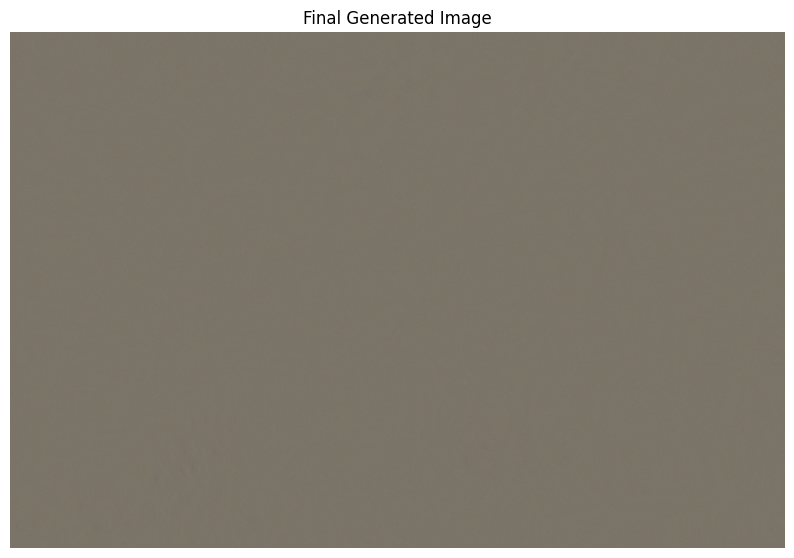

In [ ]:
# Display result
plt.figure(figsize=(10, 10))
plt.title(f'Final Generated Image')
plt.imshow(gen_img)
plt.axis('off')
plt.show()

In [ ]:
# Save result
content_name = content_img.split('/')[1].replace('.jpg', '')
style_name = style_img.split('/')[1].replace('.jpg', '')

save_path = os.path.join(save_dir, f"{content_name}_{style_name}_orig.jpg")
array_to_img(gen_img).save(save_path)
print(f"Style transfer complete! Image saved as '{content_name}_{style_name}_orig.jpg'")

Style transfer complete! Image saved as 'paris_starry_night_orig.jpg'
